In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/MyDrive/Testing_data 09 11 2025")

In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [ ]:
# --- USER CONFIGURATION ---
# 1. File Names
VELOCITY_FILE = '/content/drive/MyDrive/Testing_data 09 11 2025/velocity_data_09_11_2025.csv'
IMU_FILE = '/content/drive/MyDrive/Testing_data 09 11 2025/imu_calibrated_user_logic.csv'

# 2. Output File Name
OUTPUT_FILE = '/content/drive/MyDrive/Testing_data 09 11 2025/master_kalman_input.csv'

# 3. Column Names (Must match your CSVs exactly)
# Velocity CSV Columns
T_VEL_COL = 'Timestamp'          # Time column in velocity file
VEL_COL   = 'Vehicle_Speed_mps'  # Speed column

# IMU CSV Columns (Using your corrected column)
T_IMU_COL = 'Timestamp (s)'      # Time column in IMU file
ACCEL_COL = 'bias_corrected_arx_mps2' # The sign-flipped, bias-corrected accel

# 4. Resampling Settings
DT = 0.05  # Time step in seconds (20Hz)

In [ ]:
def sync_data():
    print(f"--- Loading Files ---")
    df_vel = pd.read_csv(VELOCITY_FILE)
    df_imu = pd.read_csv(IMU_FILE)

    # Ensure Timestamps are Floats
    df_vel[T_VEL_COL] = pd.to_numeric(df_vel[T_VEL_COL], errors='coerce')
    df_imu[T_IMU_COL] = pd.to_numeric(df_imu[T_IMU_COL], errors='coerce')

    # Drop rows with bad/missing data
    df_vel.dropna(subset=[T_VEL_COL, VEL_COL], inplace=True)
    df_imu.dropna(subset=[T_IMU_COL, ACCEL_COL], inplace=True)

    # --- 1. FIND THE OVERLAP ---
    # We can only interpolate where we have data for BOTH sensors.
    start_vel = df_vel[T_VEL_COL].min()
    end_vel   = df_vel[T_VEL_COL].max()

    start_imu = df_imu[T_IMU_COL].min()
    end_imu   = df_imu[T_IMU_COL].max()

    # The valid window starts at the LATEST start time and ends at the EARLIEST end time.
    start_overlap = max(start_vel, start_imu)
    end_overlap   = min(end_vel, end_imu)

    print(f"\n--- Synchronization Window ---")
    print(f"Velocity Range: {start_vel:.2f} to {end_vel:.2f}")
    print(f"IMU Range:      {start_imu:.2f} to {end_imu:.2f}")
    print(f"Overlap Window: {start_overlap:.2f} to {end_overlap:.2f}")

    if end_overlap <= start_overlap:
        print("ERROR: No time overlap found! Check if one is Epoch (176...) and other is Relative (0.0...).")
        return

    # --- 2. CREATE MASTER TIME VECTOR ---
    # Create a perfectly spaced grid: t, t+dt, t+2dt...
    master_time = np.arange(start_overlap, end_overlap, DT)

    print(f"Generating {len(master_time)} synchronized points (dt={DT}s)")

    # --- 3. INTERPOLATION ---
    # Create function f(t) = velocity
    f_vel = interp1d(df_vel[T_VEL_COL], df_vel[VEL_COL], kind='linear', fill_value="extrapolate")

    # Create function f(t) = acceleration
    f_acc = interp1d(df_imu[T_IMU_COL], df_imu[ACCEL_COL], kind='linear', fill_value="extrapolate")

    # Evaluate both functions on the SAME master_time grid
    vel_synced = f_vel(master_time)
    acc_synced = f_acc(master_time)

    # --- 4. ASSEMBLE & SAVE ---
    df_master = pd.DataFrame({
        'Timestamp': master_time,
        'dt': DT,  # Constant time step
        'Velocity_Meas': vel_synced,
        'Accel_Meas': acc_synced
    })

    # Create a 'Time_Rel' column (0, 0.05, 0.10...) for easier plotting/slicing later
    df_master['Time_Rel'] = df_master['Timestamp'] - df_master['Timestamp'].iloc[0]

    df_master.to_csv(OUTPUT_FILE, index=False)
    print(f"\nSuccess! Saved synchronized data to: {OUTPUT_FILE}")

    # --- PLOT TO VERIFY ALIGNMENT ---
    plt.figure(figsize=(10, 8))

    plt.subplot(2,1,1)
    plt.title("Synchronized Data Check")
    plt.plot(df_master['Time_Rel'], df_master['Velocity_Meas'], 'b-', label='Velocity (Interp)')
    plt.ylabel('Speed (m/s)')
    plt.grid(True)
    plt.legend()

    plt.subplot(2,1,2)
    plt.plot(df_master['Time_Rel'], df_master['Accel_Meas'], 'r-', label='Accel (Interp)')
    plt.ylabel('Accel (m/s^2)')
    plt.xlabel('Time Relative (s)')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()
    return df_master

--- Loading Files ---

--- Synchronization Window ---
Velocity Range: 1762673685.37 to 1762691334.10
IMU Range:      1762658331.95 to 1762691725.30
Overlap Window: 1762673685.37 to 1762691334.10
Generating 352975 synchronized points (dt=0.05s)

Success! Saved synchronized data to: /content/drive/MyDrive/Testing_data 09 11 2025/master_kalman_input.csv


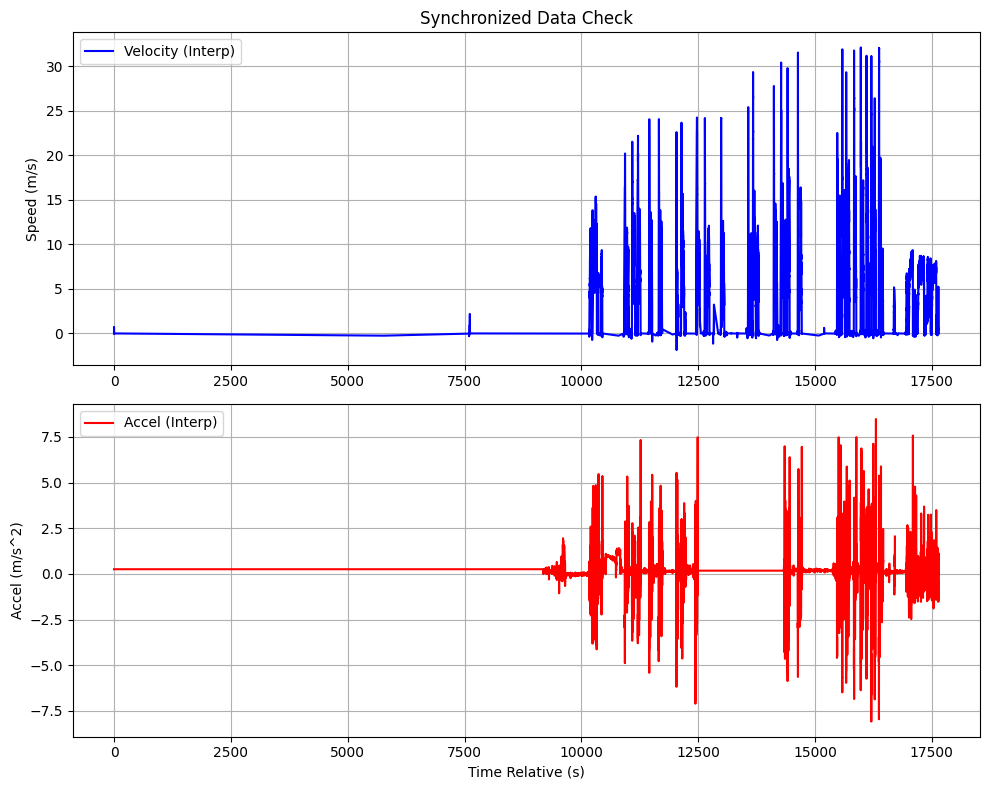

In [ ]:
df_master_kalman=sync_data()

In [ ]:
df_master_kalman

,Timestamp,dt,Velocity_Meas,Accel_Meas,Time_Rel
0,1.762674e+09,0.05,-0.021632,0.255013,0.000000
1,1.762674e+09,0.05,0.730997,0.255013,0.050000
2,1.762674e+09,0.05,0.000000,0.255013,0.100000
3,1.762674e+09,0.05,0.000000,0.255013,0.150000
4,1.762674e+09,0.05,0.000000,0.255013,0.200000
...,...,...,...,...,...
352970,1.762691e+09,0.05,0.000000,0.156899,17648.483169
352971,1.762691e+09,0.05,-0.005768,0.156899,17648.533169
352972,1.762691e+09,0.05,-0.012793,0.156899,17648.583169
352973,1.762691e+09,0.05,-0.004351,0.156899,17648.633169
